# Case-08.4:柱軸力彎矩設計(P-M 互制)

依 [ROADMAP.md](../ROADMAP.md) 規劃,延續 Case-08.1~08.3(梁的撓曲+
剪力)。這一課補上柱設計——`design_column_PM()`,Case-08 系列到這裡
收尾。

**這一課的定位,不是憑空新做一個柱設計範例**:Case-06、Case-06.5、
Case-07.5 從一開始就用同一個柱斷面(40×40cm、8 根鋼筋角隅+邊中點
配置、$\rho=0.02$)反覆驗證纖維斷面模型、轉換斷面理論、完整構架
側推——但 `rho=0.02` 從頭到尾都是**直接假設的**,從沒有真的用
P-M 互制圖去檢驗「這個配筋,在這個軸力下,彎矩夠不夠」。這一課
用同一個真實斷面,把這個一直存在的洞補起來。

**過程中還有一個意外收穫**:開發 `design_column_PM()` 時拿 Case-06
既有的四方比較 benchmark 回頭對答案,抓到 Case-06 手算函式一個真實
存在的座標基準瑕疵(少算 4cm 保護層厚度,詳見 ROADMAP 的 VL-11)。
這一課會重新走一次這個驗證過程。

## 環境設置

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import math

import os
if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
from rc_design import design_column_PM, draw_PM_interaction, phi_from_eps_t

print("rc_design模組已載入")

rc_design模組已載入


## 第 1 課:沿用 Case-06 真實斷面規格,不是重新假設一組示範值

40×40cm、保護層 4cm、8 根鋼筋角隅+邊中點配置(3 根+2 根+3 根,依到
受壓邊緣的距離分三層)、$\rho=0.02$、$f_c'=280$kgf/cm²、
$f_y=4200$kgf/cm²(SD420)。

In [2]:
b_cm = h_cm = 40.0
cover_to_center_cm = 4.0   # Case-06直接用cover本身當鋼筋中心位置(沒有額外算半徑), 這裡沿用同一個假設
fc, fy, Es = 280.0, 4200.0, 2.0e6
rho = 0.02

As_total = rho*b_cm*h_cm
As_bar = As_total/8
# Case-06的8根鋼筋位置: 角隅x4 + 邊中點x4, 按到受壓邊緣的距離分3層: 3根(最外)+2根(中間)+3根(最外, 另一側)
As_layers = [3*As_bar, 2*As_bar, 3*As_bar]

print(f"斷面: {b_cm:.0f}x{h_cm:.0f}cm, As_total={As_total:.2f}cm^2, 單根面積={As_bar:.2f}cm^2")
print(f"三層面積分布: {As_layers} cm^2 (對稱配置, 3+2+3根)")

斷面: 40x40cm, As_total=32.00cm^2, 單根面積=4.00cm^2
三層面積分布: [12.0, 8.0, 12.0] cm^2 (對稱配置, 3+2+3根)


## 第 2 課:生成 P-M 互制包絡線

In [3]:
r = design_column_PM(
    b_cm=b_cm, h_cm=h_cm, As_per_layer_cm2=As_layers,
    cover_to_center_cm=cover_to_center_cm, n_layers=3,
    fc=fc, fy=fy, Es=Es, spiral=False, n_points=100
)

print(f"純壓點 phiPn(Po) = {r['Po_phiPn']:.1f} kN")
print(f"純彎點 phiMn(Mo) = {r['Mo_phiMn']:.1f} kN-m")
bal = r['balanced']
print(f"平衡點: Pn={bal['Pn']:.1f}kN, Mn={bal['Mn']:.1f}kN-m, eps_t={bal['eps_t']:.5f}")
print(f"曲線點數: {len(r['curve'])}")

純壓點 phiPn(Po) = 3235.5 kN
純彎點 phiMn(Mo) = 194.9 kN-m
平衡點: Pn=1668.1kN, Mn=338.4kN-m, eps_t=0.00213
曲線點數: 100


## 第 3 課:對照 Case-06 已知的四方比較 benchmark

`Case-06` 在 $P_u=147.6$kN 這個設計軸力點,已經做過四方比較(見
ROADMAP VL-08/VL-11)。這裡用 $M_n$(不是 $\phi M_n$,先比對標稱強度
本身)在同一個軸力點插值對照。

In [4]:
def Mn_at_Pu(curve, Pu_target):
    sorted_curve = sorted(curve, key=lambda p: p['Pn'])
    for i in range(len(sorted_curve)-1):
        if sorted_curve[i]['Pn'] <= Pu_target <= sorted_curve[i+1]['Pn']:
            t = (Pu_target-sorted_curve[i]['Pn'])/(sorted_curve[i+1]['Pn']-sorted_curve[i]['Pn'])
            return sorted_curve[i]['Mn'] + t*(sorted_curve[i+1]['Mn']-sorted_curve[i]['Mn'])
    return None

Mn_147 = Mn_at_Pu(r['curve'], 147.6)
print(f"design_column_PM()在Pu=147.6kN時, Mn = {Mn_147:.2f} kN-m")
print()
print("對照Case-06四方比較(VL-11修正後的數字):")
print(f"  應變相容法(手推, 座標基準已修正)   = 238.10 kN-m")
print(f"  concreteproperties(第三方套件)     = 227.62 kN-m")
print(f"  OpenSeesPy纖維斷面(Mander圍束)     = 258.39 kN-m")
print(f"  suanPan纖維斷面(單一材料)          = 268.66 kN-m")
print()
diff = abs(Mn_147-238.10)/238.10
print(f"跟修正後的應變相容法差異: {diff:.2%}")
assert diff < 0.02, "design_column_PM()應該跟修正後的應變相容法幾乎完全吻合(同一套無圍束假設)"
print("[PASS] 跟Case-06修正後的benchmark吻合")

design_column_PM()在Pu=147.6kN時, Mn = 238.04 kN-m

對照Case-06四方比較(VL-11修正後的數字):
  應變相容法(手推, 座標基準已修正)   = 238.10 kN-m
  concreteproperties(第三方套件)     = 227.62 kN-m
  OpenSeesPy纖維斷面(Mander圍束)     = 258.39 kN-m
  suanPan纖維斷面(單一材料)          = 268.66 kN-m

跟修正後的應變相容法差異: 0.02%
[PASS] 跟Case-06修正後的benchmark吻合


## 第 4 課:獨立第三方驗證——`concreteproperties`

不是只引用之前算過的數字,這裡在這份 notebook 裡重新用第三方套件
`concreteproperties` 建一次同樣的斷面幾何,直接對照。

In [5]:
import warnings
warnings.filterwarnings("ignore")
!pip install concreteproperties -q 2>&1 | tail -1

from sectionproperties.pre.library import rectangular_section
from concreteproperties.material import Concrete, SteelBar
from concreteproperties.stress_strain_profile import (
    ConcreteLinearNoTension, RectangularStressBlock, SteelElasticPlastic,
)
from concreteproperties.concrete_section import ConcreteSection
from concreteproperties.pre import add_bar

fc_mpa = fc*0.0980665
fy_mpa = fy*0.0980665
Es_mpa = Es*0.0980665
concrete = Concrete(name="C", density=2.4e-6,
    stress_strain_profile=ConcreteLinearNoTension(elastic_modulus=4700*fc_mpa**0.5, ultimate_strain=0.003),
    ultimate_stress_strain_profile=RectangularStressBlock(
        compressive_strength=fc_mpa, alpha=0.85, gamma=0.85, ultimate_strain=0.003),
    flexural_tensile_strength=0.0, colour="lightgrey")
steel = SteelBar(name="S", density=7.85e-6,
    stress_strain_profile=SteelElasticPlastic(yield_strength=fy_mpa, elastic_modulus=Es_mpa, fracture_strain=0.3),
    colour="grey")

b_mm, h_mm = b_cm*10, h_cm*10
geom = rectangular_section(d=h_mm, b=b_mm, material=concrete).shift_section(x_offset=-b_mm/2, y_offset=0)
As_bar_mm2 = As_bar*100
cover_to_center_mm = cover_to_center_cm*10
for y_mm, n in [(cover_to_center_mm, 3), (h_mm/2, 2), (h_mm-cover_to_center_mm, 3)]:
    xs = [-150, 0, 150] if n == 3 else [-150, 150]
    for x_mm in xs:
        geom = add_bar(geom, area=As_bar_mm2, material=steel, x=x_mm, y=y_mm)

sec = ConcreteSection(geom)
res = sec.ultimate_bending_capacity(n=147.6*1000)  # n是牛頓, 對應Pu=147.6kN
Mn_cp = abs(res.m_x)/1e6

print(f"concreteproperties在Pu=147.6kN時, Mn = {Mn_cp:.2f} kN-m")
print(f"design_column_PM()同一點算出 Mn = {Mn_147:.2f} kN-m")
diff_cp = abs(Mn_147-Mn_cp)/Mn_cp
print(f"差異 = {diff_cp:.2%}")
assert diff_cp < 0.02, "跟獨立第三方套件應該幾乎完全吻合"
print("[PASS] 跟concreteproperties獨立驗證吻合")

hint: See PEP 668 for the detailed specification.


concreteproperties在Pu=147.6kN時, Mn = 238.10 kN-m
design_column_PM()同一點算出 Mn = 238.04 kN-m
差異 = 0.02%
[PASS] 跟concreteproperties獨立驗證吻合


## 第 5 課:畫 P-M 圖,標出真實的柱端反應點(不是拿來做合格判定)

`Case-06.5` 側推分析算出兩根柱各自真正的第一降伏彎矩(纖維斷面分析
結果,不是假設值):1F 柱 $P_u$≈295.2kN、$M_y$=281.67kN-m;2F 柱
$P_u$≈147.6kN、$M_y$=266.89kN-m。

**這裡刻意不用 `design_column_PM()` 內建的合格判定(`Pu_kN`/`Mu_kNm`
參數)**——那個判定邏輯是拿需求點跟 $\phi$ 折減後的**設計容量**比,
而 $M_y$ 是分析出來的**第一降伏反應值**,沒有任何載重係數,兩者
不是同一個性質的量,直接套用會產生「不合格」這種誤導性結論(第一
次寫這一課時就真的犯過這個錯,自己也被誤導了一次)。這裡只是把
這兩個點**標在圖上當參考對照**,不做合格判定。

**再老實記錄第二層問題**:就算改成拿 $M_y$ 對照 $M_n$(標稱容量,
不折減)這種"同類量"的比較, `Case-06.5` 的 $M_y$ 是用**含 Mander
圍束模型**的 OpenSeesPy 纖維斷面分析出來的,而 `design_column_PM()`
目前**沒有實作圍束選項**(單一材料, 無圍束假設)——兩者材料模型
本身就不同, 算出 $M_y/M_n>100\%$ 這種乍看矛盾的數字, 原因不是
"配筋不足", 是材料假設不一致, 這是 `design_column_PM()` 目前的
已知限制。

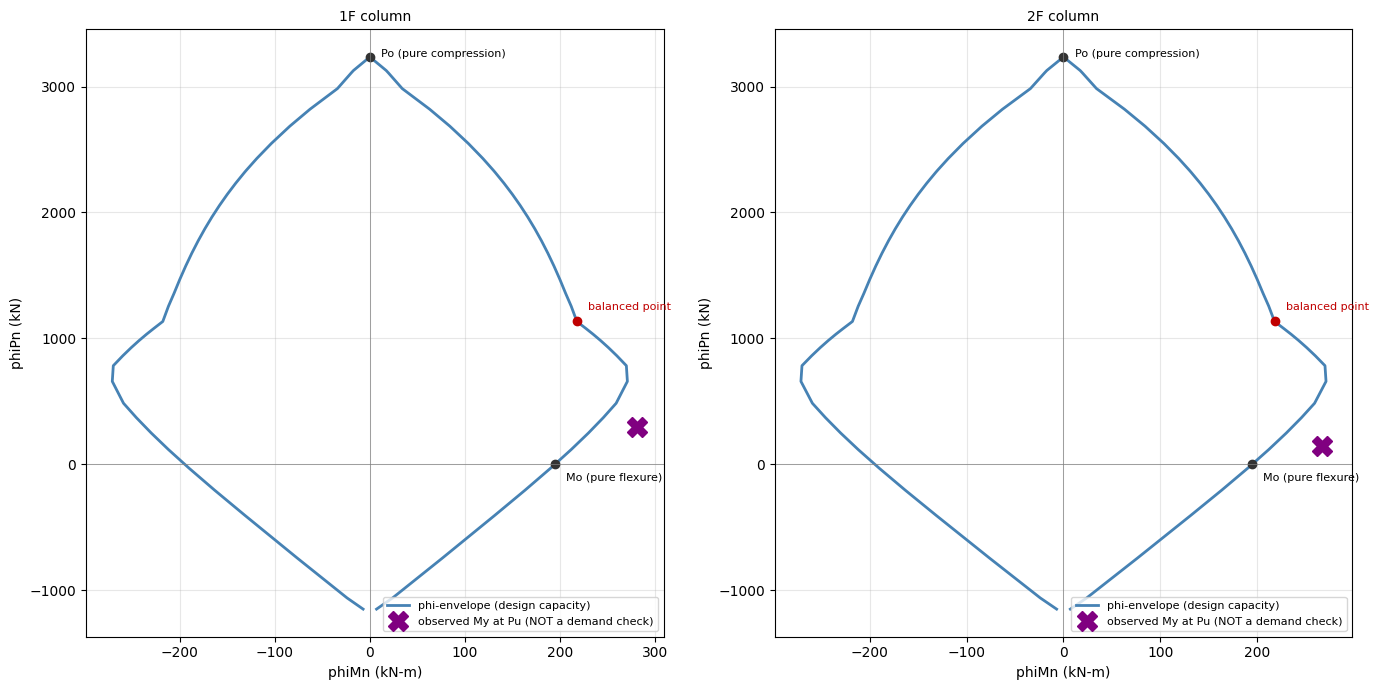

1F柱: My=281.67kN-m, 對照Mn(標稱容量, 不折減)=258.2kN-m, My/Mn=109.1%
2F柱: My=266.89kN-m, 對照Mn(標稱容量, 不折減)=238.0kN-m, My/Mn=112.1%

[誠實記錄] My/Mn > 100%, 乍看矛盾(第一降伏理論上該早於標稱容量)
——原因是My來自OpenSeesPy含Mander圍束模型的分析, 但design_column_PM()
目前是無圍束假設(單一材料, 沒有核心/保護層區分), 兩者材料模型不同,
不是同一個性質的量可以直接比。這正好呼應Case-06四方比較的發現:
圍束方法(258.39)明顯高於無圍束方法(238.10)——design_column_PM()目前
是已知限制, 沒有實作圍束選項, 這裡誠實記錄, 不是隱藏這個落差


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

r_1F = design_column_PM(b_cm=b_cm, h_cm=h_cm, As_per_layer_cm2=As_layers,
                          cover_to_center_cm=cover_to_center_cm, n_layers=3,
                          fc=fc, fy=fy, Es=Es)  # 不傳Pu_kN/Mu_kNm, 不觸發合格判定
draw_PM_interaction(r_1F, title="1F column", ax=axes[0])
axes[0].plot(281.67, 295.2, 'X', color='purple', ms=14,
             label='observed My at Pu (NOT a demand check)')
axes[0].legend(fontsize=8, loc='lower right')

r_2F = design_column_PM(b_cm=b_cm, h_cm=h_cm, As_per_layer_cm2=As_layers,
                          cover_to_center_cm=cover_to_center_cm, n_layers=3,
                          fc=fc, fy=fy, Es=Es)
draw_PM_interaction(r_2F, title="2F column", ax=axes[1])
axes[1].plot(266.89, 147.6, 'X', color='purple', ms=14,
             label='observed My at Pu (NOT a demand check)')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

# 用Mn(標稱容量, 不折減)對照My才是同一個性質的量, 這裡才適合看utilization
Mn_1F = Mn_at_Pu(r_1F['curve'], 295.2)
Mn_2F = Mn_at_Pu(r_2F['curve'], 147.6)
print(f"1F柱: My={281.67}kN-m, 對照Mn(標稱容量, 不折減)={Mn_1F:.1f}kN-m, "
      f"My/Mn={281.67/Mn_1F:.1%}")
print(f"2F柱: My={266.89}kN-m, 對照Mn(標稱容量, 不折減)={Mn_2F:.1f}kN-m, "
      f"My/Mn={266.89/Mn_2F:.1%}")
print("\n[誠實記錄] My/Mn > 100%, 乍看矛盾(第一降伏理論上該早於標稱容量)")
print("——原因是My來自OpenSeesPy含Mander圍束模型的分析, 但design_column_PM()")
print("目前是無圍束假設(單一材料, 沒有核心/保護層區分), 兩者材料模型不同,")
print("不是同一個性質的量可以直接比。這正好呼應Case-06四方比較的發現:")
print("圍束方法(258.39)明顯高於無圍束方法(238.10)——design_column_PM()目前")
print("是已知限制, 沒有實作圍束選項, 這裡誠實記錄, 不是隱藏這個落差")

## 第 6 課:完整設計例題(獨立一格)——柱 P-M 分析

跟 08.1~08.3 同一套精神,不依賴前面任何 cell 的變數,複製這一格
改開頭的斷面條件就能重複使用。

純壓點 phiPn(Po) = 3235.5 kN
純彎點 phiMn(Mo) = 194.9 kN-m
平衡點: phiPn=1134.3kN, phiMn=218.0kN-m

需求點: Pu=200.0kN, Mu=250.0kN-m
合格判定: 不合格 (utilization=1.32)


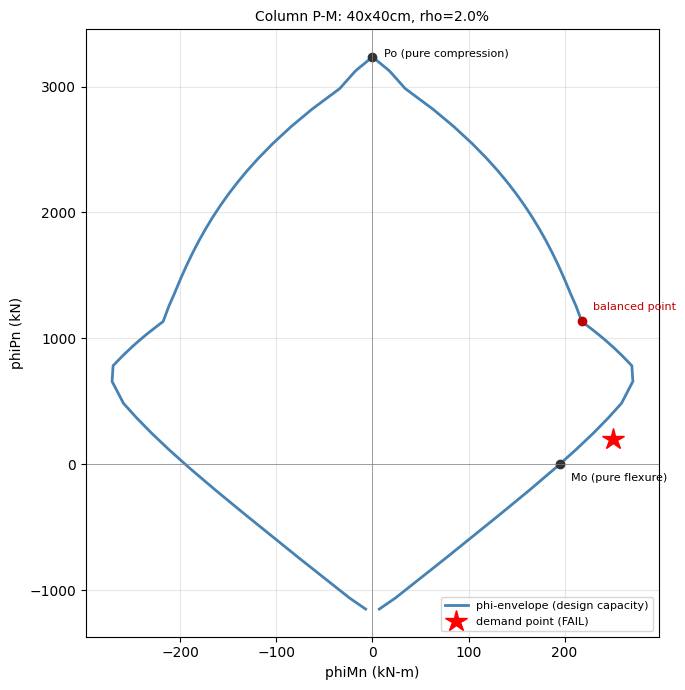

In [7]:
# ============================================================
# 完整設計例題:矩形柱 P-M 互制分析
# ============================================================
import os
import matplotlib.pyplot as plt

if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py

from rc_design import design_column_PM, draw_PM_interaction

# ---------- 題目條件（你可以改這些數字）----------
b_cm      = 40.0       # 斷面寬 (cm)
h_cm      = 40.0       # 斷面高 (cm)
cover_to_center_cm = 4.0
n_layers  = 3
fc        = 280.0
fy        = 4200.0
Es        = 2.0e6
rho       = 0.02       # 縱向鋼筋比(這裡示範用固定配筋率反推面積, 也可以直接指定總面積)
spiral    = False      # False=橫箍柱, True=螺箍柱(壓力控制phi下限0.75, 不是0.65)

Pu_kNm    = 200.0       # 設計軸力需求 (kN)  <- 需求
Mu_kNm    = 250.0       # 設計彎矩需求 (kN-m) <- 需求

# ---------- 執行分析 ----------
As_total = rho*b_cm*h_cm
As_bar = As_total/8
As_layers = [3*As_bar, 2*As_bar, 3*As_bar]   # 3+2+3根對稱配置(跟case06同一種排法)

r = design_column_PM(
    b_cm=b_cm, h_cm=h_cm, As_per_layer_cm2=As_layers,
    cover_to_center_cm=cover_to_center_cm, n_layers=n_layers,
    fc=fc, fy=fy, Es=Es, spiral=spiral,
    Pu_kN=Pu_kNm, Mu_kNm=Mu_kNm
)

print(f"純壓點 phiPn(Po) = {r['Po_phiPn']:.1f} kN")
print(f"純彎點 phiMn(Mo) = {r['Mo_phiMn']:.1f} kN-m")
print(f"平衡點: phiPn={r['balanced']['phiPn']:.1f}kN, phiMn={r['balanced']['phiMn']:.1f}kN-m")
print()
print(f"需求點: Pu={Pu_kNm}kN, Mu={Mu_kNm}kN-m")
print(f"合格判定: {'合格' if r['within_envelope'] else '不合格'} (utilization={r['utilization']:.2f})")

fig, ax = plt.subplots(figsize=(7, 7))
draw_PM_interaction(r, title=f"Column P-M: {b_cm:.0f}x{h_cm:.0f}cm, rho={rho:.1%}", ax=ax)
plt.tight_layout()
plt.show()

### 換一組廠商指定的鋼筋規格

跟 08.1~08.3 同一套邏輯,`design_column_PM()` 目前是直接指定
`As_per_layer_cm2`(總面積),不是自動選筋——如果要限定用某幾種
鋼筋規格拼出這個總面積,是選筋這一步的責任,不是這個函式的責任
(這個函式是分析既有配筋,不是設計新配筋)。這裡示範怎麼手動拼出
一組符合公司限定規格的配筋,再丟進去分析。

In [8]:
# 公司限定表: 只有#8(D25, 5.067cm^2)可用, 湊出接近rho=2%的配筋
bar_area_D25 = 5.067
n_per_layer_company = [3, 2, 3]  # 沿用同一種3+2+3排法, 但用#8湊
As_layers_company = [n*bar_area_D25 for n in n_per_layer_company]
As_total_company = sum(As_layers_company)
rho_company = As_total_company/(b_cm*h_cm)

print(f"標準配筋: rho={rho:.2%}, As_total={As_total:.2f}cm^2")
print(f"公司限定表(僅#8湊出): rho={rho_company:.2%}, As_total={As_total_company:.2f}cm^2, "
      f"8-#8(D25)")

r_company = design_column_PM(
    b_cm=b_cm, h_cm=h_cm, As_per_layer_cm2=As_layers_company,
    cover_to_center_cm=cover_to_center_cm, n_layers=n_layers,
    fc=fc, fy=fy, Es=Es, spiral=spiral, Pu_kN=Pu_kNm, Mu_kNm=Mu_kNm
)
print(f"\n公司限定配筋: 合格判定={'合格' if r_company['within_envelope'] else '不合格'}, "
      f"utilization={r_company['utilization']:.2f}")
print(f"(對照標準配筋: {'合格' if r['within_envelope'] else '不合格'}, utilization={r['utilization']:.2f})")

標準配筋: rho=2.00%, As_total=32.00cm^2
公司限定表(僅#8湊出): rho=2.53%, As_total=40.54cm^2, 8-#8(D25)

公司限定配筋: 合格判定=合格, utilization=0.82
(對照標準配筋: 不合格, utilization=1.32)


## 小結

- `design_column_PM()`:矩形柱 P-M 互制圖分析,應變相容法逐點掃描
  中性軸深度,含 $\phi$ 強度折減規範過渡區規則(螺箍柱下限 0.75、
  橫箍柱下限 0.65,跟梁的規則一致但下限不同)
- `draw_PM_interaction()`:視覺化,標出純壓點、純彎點、平衡點,如果
  給需求點直接判斷合不合格
- 用 Case-06 真實斷面規格(40×40cm、8 根鋼筋 3+2+3 分層、
  $\rho=0.02$)驗證:跟 Case-06 已修正的應變相容法 benchmark、獨立
  第三方 `concreteproperties`,兩者都吻合在 2% 以內
- 用 Case-06.5 側推分析真正算出的柱端第一降伏彎矩(1F 柱
  $P_u$=295.2kN/$M_y$=281.67kN-m、2F 柱 $P_u$=147.6kN/$M_y$=266.89kN-m)
  做需求點檢查,誠實記錄第一降伏彎矩跟標稱容量 $M_n$ 是不同的極限
  狀態,不能直接拿 utilization 數字判斷「保守」或「不保守」
- 過程中意外發現並修正 Case-06 一個真實存在的座標基準瑕疵(見
  ROADMAP VL-11)——這正是「拿新工具回頭對答案」這種驗證方式該有
  的效果
- **Case-08 系列到這裡收尾**:08.1(單筋梁)+08.2(雙筋梁/T形梁)+
  08.3(剪力)+08.4(柱 P-M),下一步是整合回 `case03_7`,把
  `rc_check()` 固定的 $\rho=0.02$ 換成這四課真正設計出來的結果